Valence 95 percentile : 0.825
Arousal 95 percentile : 0.863

========== Valence Change Candidates ==========
0054_L.wav   <笑>                       Residual= 0.944
0116_L.wav   <笑>                       Residual= 0.932
0120_L.wav   <笑>                       Residual= 0.945
0130_L.wav   (D2 お)                    Residual=-0.873
0134_L.wav   <笑>                       Residual= 0.976
0207_L.wav   <笑>                       Residual= 0.825
0209_L.wav   <笑>                       Residual= 0.860
0256_L.wav   <笑>                       Residual= 0.849
0295_L.wav   凄い力ですよね                   Residual= 1.039
0334_L.wav   <笑>                       Residual= 0.969
0374_L.wav   そうですね                     Residual= 0.856
0445_L.wav   <笑>                       Residual= 0.885
0500_L.wav   <笑>                       Residual= 0.868
0502_L.wav   <笑>                       Residual= 0.896

========== Arousal Change Candidates ==========
0054_L.wav   <笑>                       Residual= 0.935
0116_L.wav   <笑> 

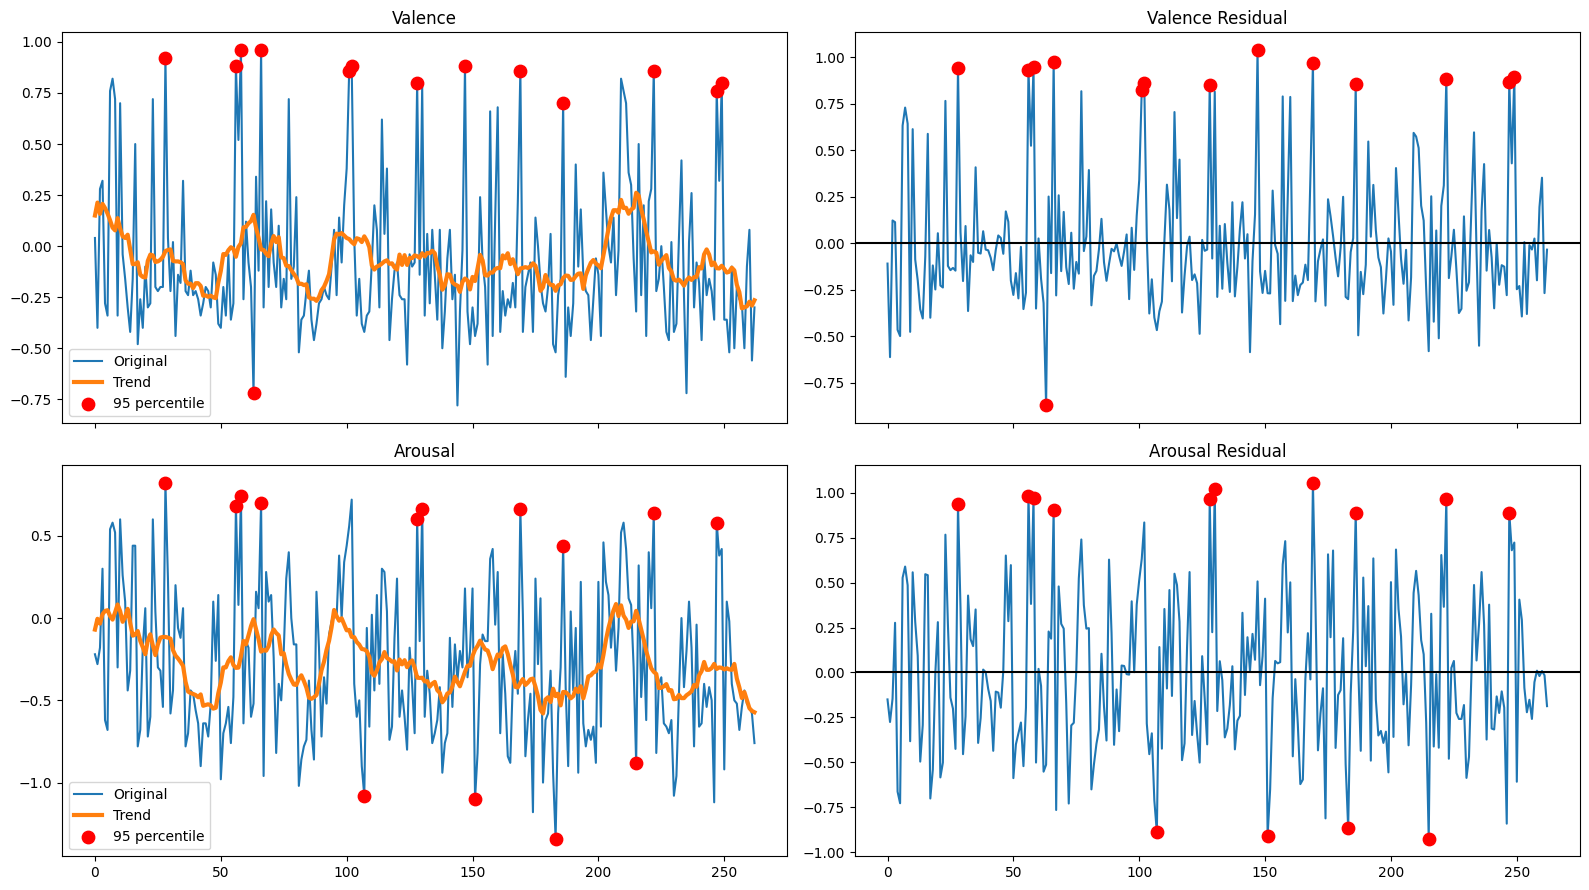

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load
# ==========================

path = "/home/mitani/CSJ-emo-int_bunseki/0718/L_bunseki/vad_dis.csv"
df = pd.read_csv(path)

# Valence, Arousal
v = df["valence"].astype(float).values
a = df["arousal"].astype(float).values

# -1～1へ変換
v = v * 2 - 1
a = a * 2 - 1

# ==========================
# Moving Average Trend
# ==========================

window = 15

v_trend = (
    pd.Series(v)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)

a_trend = (
    pd.Series(a)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)

# ==========================
# Residual
# ==========================

v_residual = v - v_trend
a_residual = a - a_trend

# ==========================
# 95 percentile
# ==========================

v_abs = np.abs(v_residual)
a_abs = np.abs(a_residual)

v_threshold = np.percentile(v_abs, 95)
a_threshold = np.percentile(a_abs, 95)

print("=" * 50)
print(f"Valence 95 percentile : {v_threshold:.3f}")
print(f"Arousal 95 percentile : {a_threshold:.3f}")
print("=" * 50)

# ==========================
# Detect change candidates
# ==========================

v_idx = np.where(v_abs >= v_threshold)[0]
a_idx = np.where(a_abs >= a_threshold)[0]

# ==========================
# Print candidates
# ==========================

print("\n========== Valence Change Candidates ==========")

for idx in v_idx:
    print(
        f"{df.loc[idx,'filename']:12s} "
        f"{df.loc[idx,'text'][:25]:25s} "
        f"Residual={v_residual[idx]:6.3f}"
    )

print("\n========== Arousal Change Candidates ==========")

for idx in a_idx:
    print(
        f"{df.loc[idx,'filename']:12s} "
        f"{df.loc[idx,'text'][:25]:25s} "
        f"Residual={a_residual[idx]:6.3f}"
    )

# ==========================
# Save CSV
# ==========================

v_result = pd.DataFrame({
    "filename": df.loc[v_idx, "filename"].values,
    "text": df.loc[v_idx, "text"].values,
    "valence": v[v_idx],
    "trend": v_trend[v_idx],
    "residual": v_residual[v_idx],
    "abs_residual": v_abs[v_idx]
})

a_result = pd.DataFrame({
    "filename": df.loc[a_idx, "filename"].values,
    "text": df.loc[a_idx, "text"].values,
    "arousal": a[a_idx],
    "trend": a_trend[a_idx],
    "residual": a_residual[a_idx],
    "abs_residual": a_abs[a_idx]
})

v_result.to_csv(
    "L-valence_change_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

a_result.to_csv(
    "L-arousal_change_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nCSV saved!")
print("L-valence_change_candidates.csv")
print("L-arousal_change_candidates.csv")

# ==========================
# Plot
# ==========================

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)

# -------- Valence --------

axes[0,0].plot(v, label="Original")
axes[0,0].plot(v_trend, linewidth=3, label="Trend")

axes[0,0].scatter(
    v_idx,
    v[v_idx],
    color="red",
    s=80,
    zorder=5,
    label="95 percentile"
)

axes[0,0].set_title("Valence")
axes[0,0].legend()

axes[0,1].plot(v_residual)
axes[0,1].axhline(0, color="black")

axes[0,1].scatter(
    v_idx,
    v_residual[v_idx],
    color="red",
    s=80,
    zorder=5
)

axes[0,1].set_title("Valence Residual")

# -------- Arousal --------

axes[1,0].plot(a, label="Original")
axes[1,0].plot(a_trend, linewidth=3, label="Trend")

axes[1,0].scatter(
    a_idx,
    a[a_idx],
    color="red",
    s=80,
    zorder=5,
    label="95 percentile"
)

axes[1,0].set_title("Arousal")
axes[1,0].legend()

axes[1,1].plot(a_residual)
axes[1,1].axhline(0, color="black")

axes[1,1].scatter(
    a_idx,
    a_residual[a_idx],
    color="red",
    s=80,
    zorder=5
)

axes[1,1].set_title("Arousal Residual")

plt.tight_layout()
plt.show()

Valence 95 percentile : 0.638
Arousal 95 percentile : 0.709

========== Valence Change Candidates ==========
0055_R.wav   <笑>                       Residual= 0.699
0117_R.wav   <笑>                       Residual= 0.665
0142_R.wav   <FV>(F その)                Residual=-0.701
0212_R.wav   <笑>                       Residual= 0.775
0257_R.wav   <笑>                       Residual= 0.747
0313_R.wav   <笑>                       Residual= 0.888
0315_R.wav   <笑>                       Residual= 0.779
0324_R.wav   もう本当万年睡眠不足状態              Residual=-0.763
0335_R.wav   <笑>                       Residual= 0.783
0375_R.wav   <笑>                       Residual= 0.911
0399_R.wav   赤ちゃんを触れるだけで幸せみたいなとこがありますか Residual= 0.701
0402_R.wav   <笑>                       Residual= 0.896
0421_R.wav   <笑>                       Residual= 0.768

========== Arousal Change Candidates ==========
0038_R.wav   (F うーん)                   Residual=-0.884
0059_R.wav   そうですねそんな感じのことです           Residual=-0.713
0215_R.wav   (F う

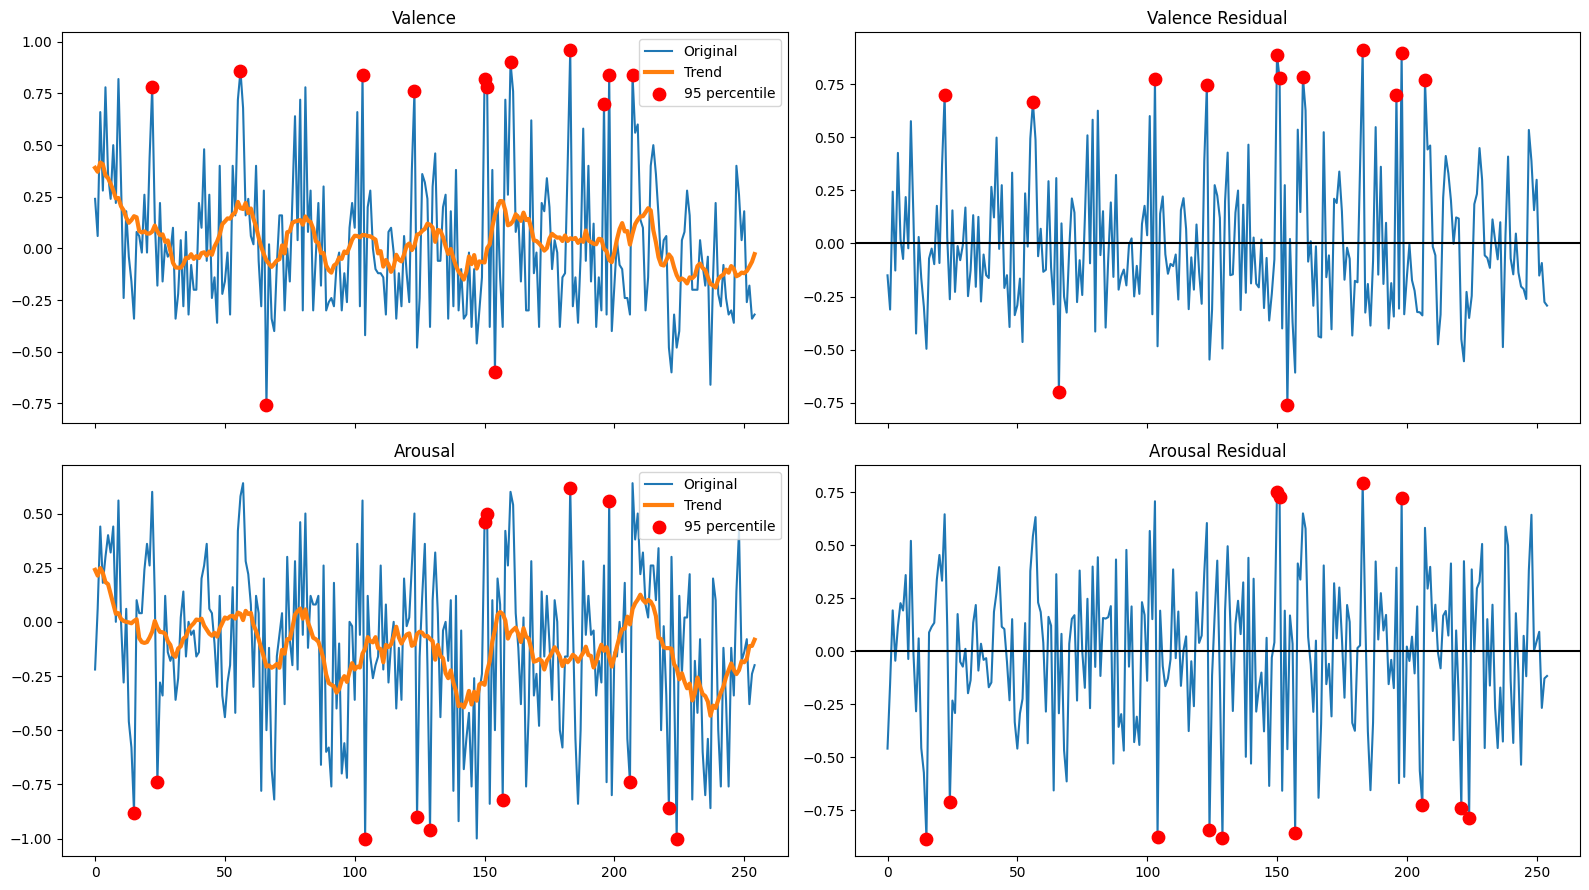

In [10]:
# Rの場合
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load
# ==========================

path = "/home/mitani/CSJ-emo-int_bunseki/0718/R_bunseki/vad_dis.csv"
df = pd.read_csv(path)

# Valence, Arousal
v = df["valence"].astype(float).values
a = df["arousal"].astype(float).values

# -1～1へ変換
v = v * 2 - 1
a = a * 2 - 1

# ==========================
# Moving Average Trend
# ==========================

window = 15

v_trend = (
    pd.Series(v)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)

a_trend = (
    pd.Series(a)
    .rolling(window=window, center=True, min_periods=1)
    .mean()
    .values
)

# ==========================
# Residual
# ==========================

v_residual = v - v_trend
a_residual = a - a_trend

# ==========================
# 95 percentile
# ==========================

v_abs = np.abs(v_residual)
a_abs = np.abs(a_residual)

v_threshold = np.percentile(v_abs, 95)
a_threshold = np.percentile(a_abs, 95)

print("=" * 50)
print(f"Valence 95 percentile : {v_threshold:.3f}")
print(f"Arousal 95 percentile : {a_threshold:.3f}")
print("=" * 50)

# ==========================
# Detect change candidates
# ==========================

v_idx = np.where(v_abs >= v_threshold)[0]
a_idx = np.where(a_abs >= a_threshold)[0]

# ==========================
# Print candidates
# ==========================

print("\n========== Valence Change Candidates ==========")

for idx in v_idx:
    print(
        f"{df.loc[idx,'filename']:12s} "
        f"{df.loc[idx,'text'][:25]:25s} "
        f"Residual={v_residual[idx]:6.3f}"
    )

print("\n========== Arousal Change Candidates ==========")

for idx in a_idx:
    print(
        f"{df.loc[idx,'filename']:12s} "
        f"{df.loc[idx,'text'][:25]:25s} "
        f"Residual={a_residual[idx]:6.3f}"
    )

# ==========================
# Save CSV
# ==========================

v_result = pd.DataFrame({
    "filename": df.loc[v_idx, "filename"].values,
    "text": df.loc[v_idx, "text"].values,
    "valence": v[v_idx],
    "trend": v_trend[v_idx],
    "residual": v_residual[v_idx],
    "abs_residual": v_abs[v_idx]
})

a_result = pd.DataFrame({
    "filename": df.loc[a_idx, "filename"].values,
    "text": df.loc[a_idx, "text"].values,
    "arousal": a[a_idx],
    "trend": a_trend[a_idx],
    "residual": a_residual[a_idx],
    "abs_residual": a_abs[a_idx]
})

v_result.to_csv(
    "R-valence_change_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

a_result.to_csv(
    "R-arousal_change_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nCSV saved!")
print("  R-valence_change_candidates.csv")
print("  R-arousal_change_candidates.csv")

# ==========================
# Plot
# ==========================

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)

# -------- Valence --------

axes[0,0].plot(v, label="Original")
axes[0,0].plot(v_trend, linewidth=3, label="Trend")

axes[0,0].scatter(
    v_idx,
    v[v_idx],
    color="red",
    s=80,
    zorder=5,
    label="95 percentile"
)

axes[0,0].set_title("Valence")
axes[0,0].legend()

axes[0,1].plot(v_residual)
axes[0,1].axhline(0, color="black")

axes[0,1].scatter(
    v_idx,
    v_residual[v_idx],
    color="red",
    s=80,
    zorder=5
)

axes[0,1].set_title("Valence Residual")

# -------- Arousal --------

axes[1,0].plot(a, label="Original")
axes[1,0].plot(a_trend, linewidth=3, label="Trend")

axes[1,0].scatter(
    a_idx,
    a[a_idx],
    color="red",
    s=80,
    zorder=5,
    label="95 percentile"
)

axes[1,0].set_title("Arousal")
axes[1,0].legend()

axes[1,1].plot(a_residual)
axes[1,1].axhline(0, color="black")

axes[1,1].scatter(
    a_idx,
    a_residual[a_idx],
    color="red",
    s=80,
    zorder=5
)

axes[1,1].set_title("Arousal Residual")

plt.tight_layout()
plt.show()

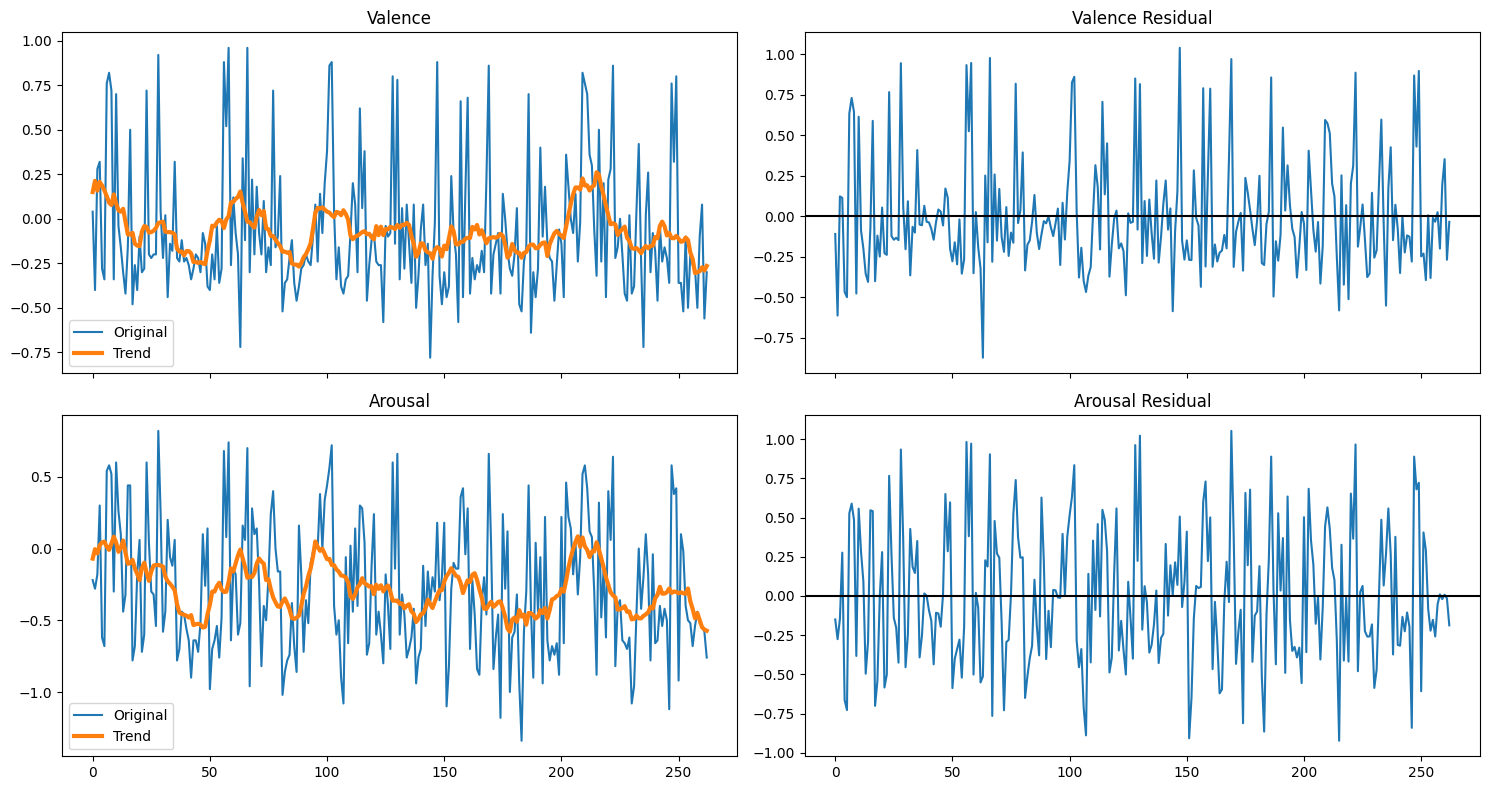

In [1]:
# Lの場合
# 例えば5〜10発話程度の移動平均や局所回帰でトレンドを求め、そのトレンドからのずれ（急な変化）と、トレンド自体の傾き（緩やかな変化）を別々に評価
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load
# ==========================

path = "/home/mitani/CSJ-emo-int_bunseki/0718/L_bunseki/vad_dis.csv"
df = pd.read_csv(path)

v = df["valence"].astype(float).values
a = df["arousal"].astype(float).values

# -1～1へ変換
v = v * 2 - 1
a = a * 2 - 1

# ==========================
# 移動平均
# ==========================

window = 15      # 5～10くらいで試す

v_trend = pd.Series(v).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

a_trend = pd.Series(a).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

# ==========================
# 急な変化（残差）
# ==========================

v_residual = v - v_trend
a_residual = a - a_trend

# ==========================
# Plot
# ==========================

fig, axes = plt.subplots(2,2, figsize=(15,8), sharex=True)

# Valence
axes[0,0].plot(v, label="Original")
axes[0,0].plot(v_trend, linewidth=3, label="Trend")
axes[0,0].set_title("Valence")
axes[0,0].legend()

axes[0,1].plot(v_residual)
axes[0,1].axhline(0,color="black")
axes[0,1].set_title("Valence Residual")

# Arousal
axes[1,0].plot(a, label="Original")
axes[1,0].plot(a_trend, linewidth=3, label="Trend")
axes[1,0].set_title("Arousal")
axes[1,0].legend()

axes[1,1].plot(a_residual)
axes[1,1].axhline(0,color="black")
axes[1,1].set_title("Arousal Residual")

plt.tight_layout()
plt.show()

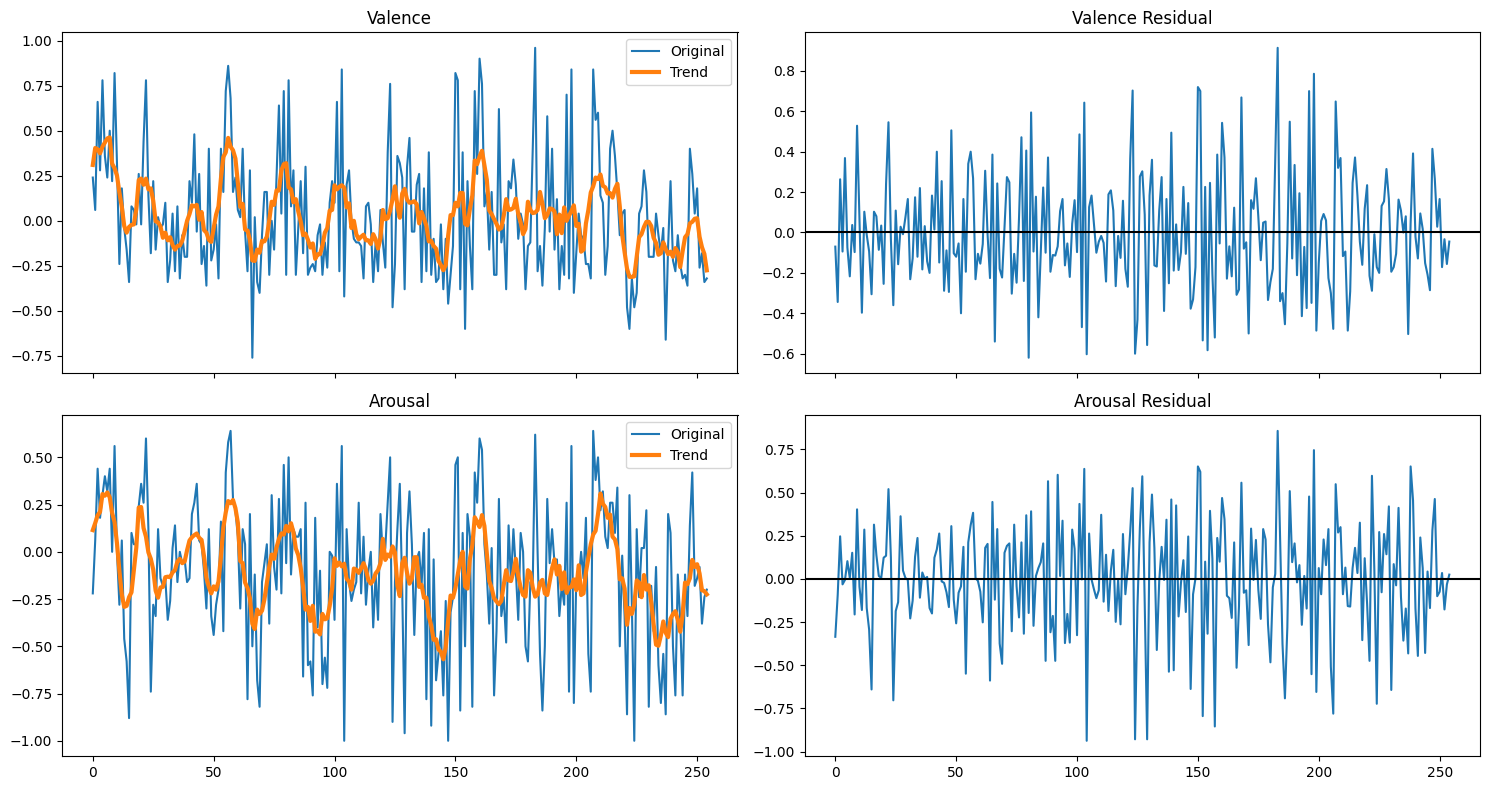

In [ ]:
# Rの場合
# 例えば5〜10発話程度の移動平均や局所回帰でトレンドを求め、そのトレンドからのずれ（急な変化）と、トレンド自体の傾き（緩やかな変化）を別々に評価
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================
# Load
# ==========================

path = "/home/mitani/CSJ-emo-int_bunseki/0718/R_bunseki/vad_dis.csv"
df = pd.read_csv(path)

v = df["valence"].astype(float).values
a = df["arousal"].astype(float).values

# -1～1へ変換
v = v * 2 - 1
a = a * 2 - 1

# ==========================
# 移動平均
# ==========================

window = 7      # 5～10くらいで試す

v_trend = pd.Series(v).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

a_trend = pd.Series(a).rolling(
    window,
    center=True,
    min_periods=1
).mean().values

# ==========================
# 急な変化（残差）
# ==========================

v_residual = v - v_trend
a_residual = a - a_trend

# ==========================
# Plot
# ==========================

fig, axes = plt.subplots(2,2, figsize=(15,8), sharex=True)

# Valence
axes[0,0].plot(v, label="Original")
axes[0,0].plot(v_trend, linewidth=3, label="Trend")
axes[0,0].set_title("Valence")
axes[0,0].legend()

axes[0,1].plot(v_residual)
axes[0,1].axhline(0,color="black")
axes[0,1].set_title("Valence Residual")

# Arousal
axes[1,0].plot(a, label="Original")
axes[1,0].plot(a_trend, linewidth=3, label="Trend")
axes[1,0].set_title("Arousal")
axes[1,0].legend()

axes[1,1].plot(a_residual)
axes[1,1].axhline(0,color="black")
axes[1,1].set_title("Arousal Residual")

plt.tight_layout()
plt.show()

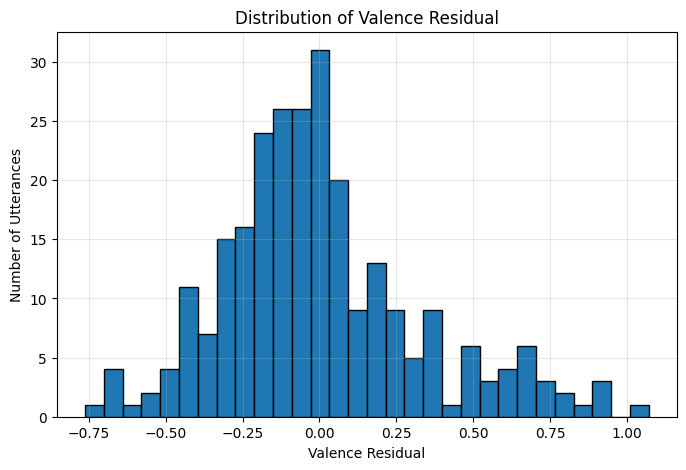

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    v_residual,
    bins=30,          # ビン数（調整可能）
    edgecolor="black"
)

plt.xlabel("Valence Residual")
plt.ylabel("Number of Utterances")
plt.title("Distribution of Valence Residual")

plt.grid(alpha=0.3)
plt.show()

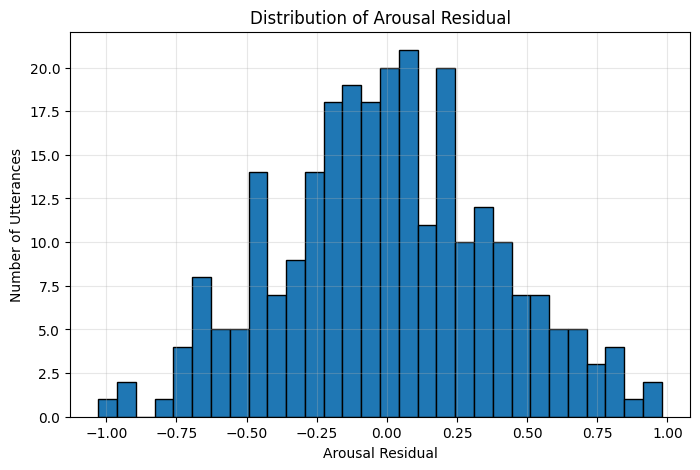

In [3]:
plt.figure(figsize=(8,5))

plt.hist(
    a_residual,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Arousal Residual")
plt.ylabel("Number of Utterances")
plt.title("Distribution of Arousal Residual")

plt.grid(alpha=0.3)
plt.show()

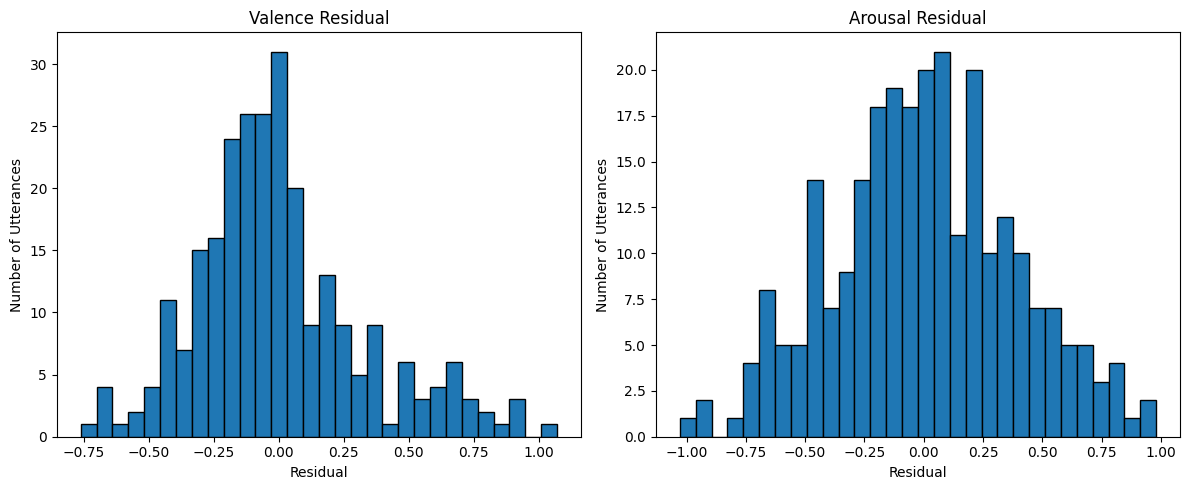

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].hist(v_residual, bins=30, edgecolor="black")
axes[0].set_title("Valence Residual")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Number of Utterances")

axes[1].hist(a_residual, bins=30, edgecolor="black")
axes[1].set_title("Arousal Residual")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Number of Utterances")

plt.tight_layout()
plt.show()

[  5   9  16  23  28  56  58  63  66  77 128 130 144 147 160 169 186 222
 247 249]


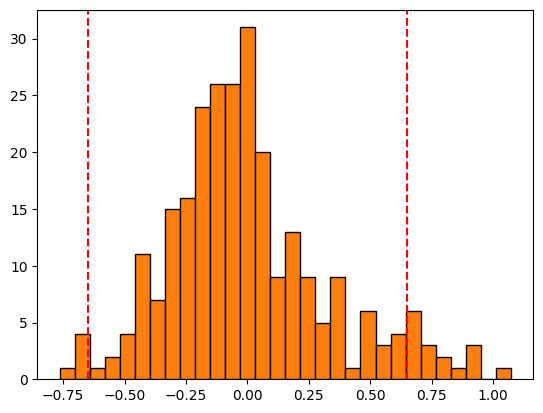

In [5]:
# 標準偏差を用いて急激な変化を検出
mean = np.mean(v_residual)
std = np.std(v_residual)

upper = mean + 2 * std
lower = mean - 2 * std

change_idx = np.where(
    (v_residual > upper) | (v_residual < lower)
)[0]

plt.hist(v_residual, bins=30)
plt.hist(v_residual, bins=30, edgecolor="black")
plt.axvline(upper, color="red", linestyle="--")
plt.axvline(lower, color="red", linestyle="--")

print(change_idx)

In [6]:
# パーセンタイルを使用して, 残差が大きい上位95%以上の発話を検出
threshold = np.percentile(np.abs(v_residual),95)

change_idx = np.where(np.abs(v_residual)>threshold)[0]
print(change_idx)

[  9  16  23  28  58  63  66  77 144 147 169 186 222 249]


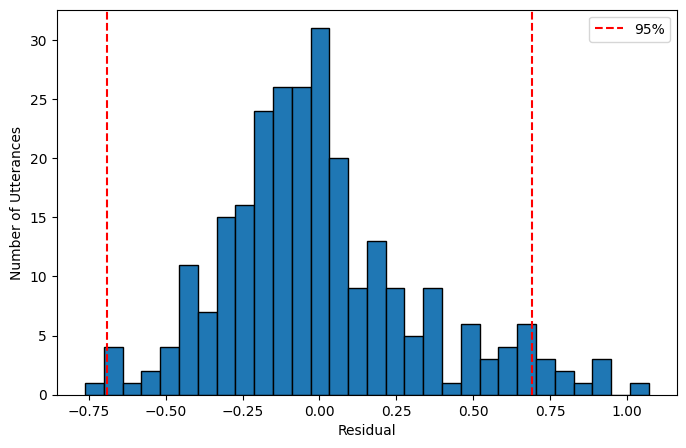

In [7]:
threshold = np.percentile(np.abs(v_residual),95)

plt.figure(figsize=(8,5))
plt.hist(v_residual, bins=30, edgecolor="black")

plt.axvline(threshold, color="red", linestyle="--", label="95%")
plt.axvline(-threshold, color="red", linestyle="--")

plt.legend()
plt.xlabel("Residual")
plt.ylabel("Number of Utterances")
plt.show()

In [8]:
# IQR（箱ひげ図を使用）
Q1 = np.percentile(v_residual,25)
Q3 = np.percentile(v_residual,75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

change_idx = np.where((v_residual<lower)|(v_residual>upper))[0]
print(change_idx)

[ 16  23  28  56  58  63  66  77 128 147 160 169 186 222 249]


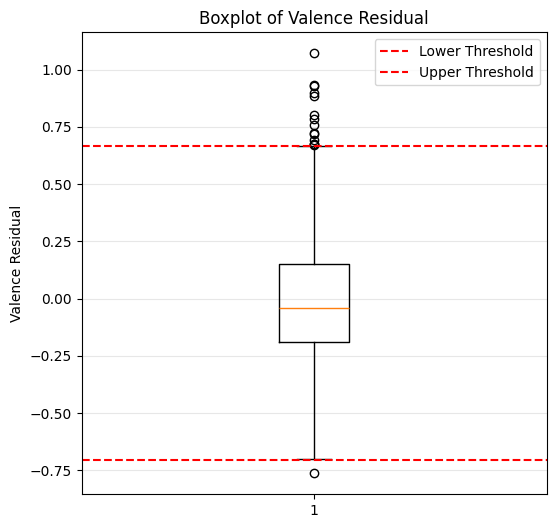

In [9]:
plt.figure(figsize=(6,6))

plt.boxplot(v_residual, showfliers=True)

plt.axhline(lower, color="red", linestyle="--", label="Lower Threshold")
plt.axhline(upper, color="red", linestyle="--", label="Upper Threshold")

plt.ylabel("Valence Residual")
plt.title("Boxplot of Valence Residual")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

In [10]:
print(f"検出された発話数: {len(change_idx)}")
print(f"全体に占める割合: {len(change_idx)/len(v_residual)*100:.1f}%")
print(len(change_idx))

検出された発話数: 15
全体に占める割合: 5.7%
15
